# H&M Fashion Recommender

## Exploratory Data Analysis & Recommendation Strategy

### Business problem

E-commerce catalogues can contain tens of thousands of products, making it difficult for customers to discover items that are relevant to them.

The goal of this project is to predict which products a customer is most likely to purchase in the following week, using their previous purchasing behaviour and product information.

Using the public H&M dataset from Kaggle, this notebook explores customer purchasing behaviour to identify which signals and modelling approaches are most promising.


## 1. Data

The dataset contains transaction history for H&M customers together with information about the products and customers.

For this analysis, we focus on purchase interactions and use the product and customer tables later to investigate whether product characteristics and customer attributes can improve recommendations.

In [35]:
import os
import sys
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyspark.sql.functions as F
from pyspark.sql import SparkSession, Window as W

sys.path.insert(0, str(Path.cwd().parent))  # repo root, for the eda/ helpers

from eda.analysis import *

%matplotlib inline

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("python:", sys.version)

pandas: 3.0.1
numpy: 2.4.2
python: 3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [36]:
spark = (
    SparkSession.builder
    .appName("hm_recommender_eda")
    .master("local[*]")
    .config("spark.driver.memory", "8g")          # 16GB machine: leave room for OS + Jupyter
    .config("spark.sql.shuffle.partitions", "32")   # ~4x cores; 200 is scheduling overhead in local mode
    .config("spark.network.timeout", "3600s")
    .config("spark.executor.heartbeatInterval", "60s")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
RAW_DIR  = Path(os.environ.get("HM_RAW_DIR",  Path.home() / "HM_dataset/hm_data"))
WORK_DIR = Path(os.environ.get("HM_WORK_DIR", Path.home() / "hm_data"))

transactions = (
    spark.read
    .option("header", True)
    .csv(str(RAW_DIR / "transactions_train.csv"))
    .withColumn("t_dat", F.to_date("t_dat", "yyyy-MM-dd"))
)

articles  = spark.read.parquet(str(WORK_DIR / "articles"))
customers = spark.read.parquet(str(WORK_DIR / "customers"))


In [ ]:
DATE = "t_dat"
CUSTOMER = "customer_id"
ITEM = "article_id"

# single pass: counts and date range together, rather than one scan each
overview = transactions.agg(
    F.count("*").alias("n_transactions"),
    F.countDistinct(CUSTOMER).alias("n_customers"),
    F.countDistinct(ITEM).alias("n_articles"),
    F.min(DATE).alias("min_date"),
    F.max(DATE).alias("max_date"),
).collect()[0]

n_transactions = overview["n_transactions"]

print(f"Transactions: {overview['n_transactions']:,}")
print(f"Customers:   {overview['n_customers']:,}")
print(f"Articles:    {overview['n_articles']:,}")
print(f"Date range:  {overview['min_date']} → {overview['max_date']}")

Transactions: 31,788,324
Customers:   1,362,281
Articles:    104,547
Date range:  2018-09-20 → 2020-09-22


### Data cleaning

The transaction table may contain multiple rows for the same customer, item, and day. For this recommendation task, we treat a customer purchasing an item on a given day as one interaction, regardless of the number of the same unit purchased.

We therefore remove duplicate customer–item–day interactions.

In [ ]:
key = [CUSTOMER, ITEM, DATE]

n_exact = transactions.distinct().count()
n_unique = transactions.select(*key).distinct().count()

transactions = (
    transactions
    .dropDuplicates(key)
    .persist()
)

print(f"Rows before cleaning:       {n_transactions:,}")
print(f"Exact duplicate rows:       {n_transactions - n_exact:,}")
print(f"Same-day repeat units:      {n_transactions - n_unique:,}")
print(f"Rows after cleaning:        {transactions.count():,}")

Rows before cleaning:       31,788,324
Exact duplicate rows:       2,974,905
Same-day repeat units:      3,212,929

Rows after cleaning:        28,575,395


## 2. Exploratory Data Analysis

### 2.1 How sparse is the recommendation problem?

Recommendation systems typically operate on sparse interaction data: each customer interacts with only a small fraction of the available catalogue.

We first quantify this sparsity to understand how much information is available for personalization and how challenging the customer–item prediction problem is.

  Interaction matrix & sparsity
  ✓ Found cached data at /tmp/eda/section1, skipping recomputation.

  n_transactions : 28,575,395
  n_users        : 1,362,281
  n_items        : 104,547
  sparsity       : 99.9799%
  cold users     : 11.0% have exactly 1 interaction
  cold items     : 4.5% have exactly 1 interaction


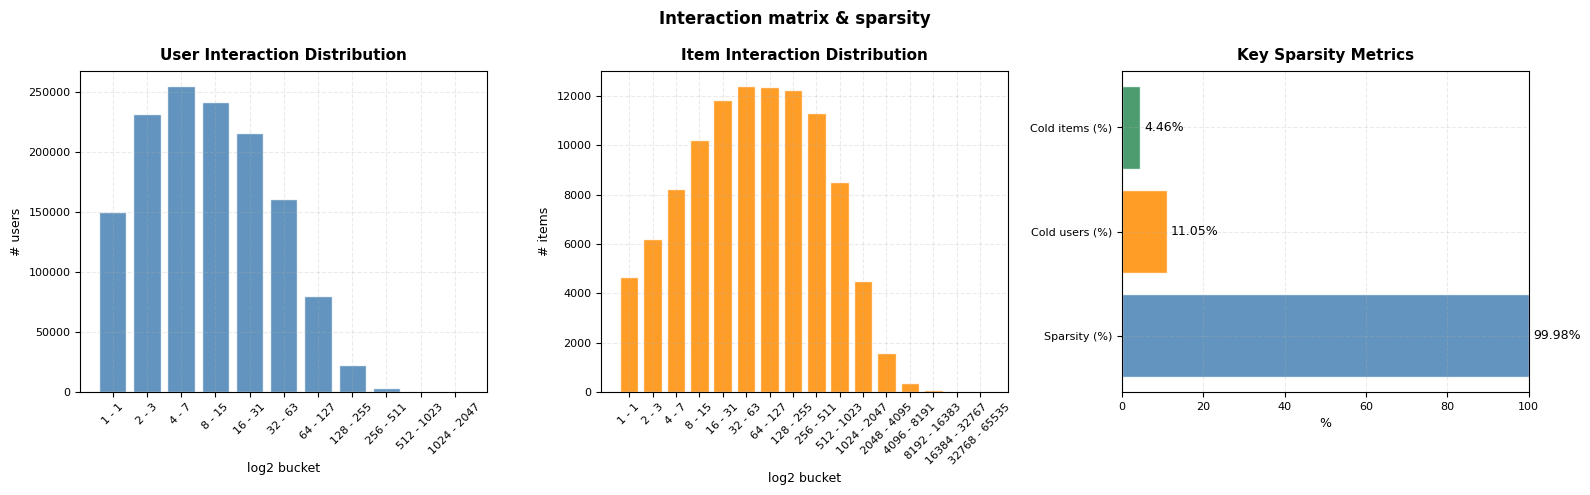

In [ ]:
fig = analyze_interaction_distribution(
    transactions=transactions,
    save_path="/tmp/eda/section1",
    spark=spark,
)

**Finding:** The customer–item interaction matrix is sparse. Most customers have bought only a few products, with 11% purchasing just once, while only 4.5% of products were
purchased a single time. We therefore have more evidence about product demand than about
individual customer preferences.

**Implication:** For many customers, personalized estimates will rely on limited
purchase history, making personalization more challenging. This suggests testing personalization against a popularity baseline to
see how much it adds, and evaluating whether its value depends on how much purchase
history a customer has.

### 2.2 How does purchasing behaviour change over time?

We examine transaction volume, active customers, the number of distinct products purchased, and average purchase price over time. The goal is to understand whether older purchasing behaviour can be treated as equally relevant, or whether recommendation strategies should place more weight on recent activity.

--- Summary ---
Date range    : 2018-09-17 → 2020-09-21
Total weeks   : 106
Peak volume   : 2019-06-24 (505,213 transactions)
Lowest volume : 2020-09-21 (58,286 transactions)
Outlier weeks : 7
  2019-06-17 — 502,160 transactions
  2019-06-24 — 505,213 transactions
  2019-07-22 — 422,181 transactions
  2019-11-25 — 451,998 transactions
  2020-06-15 — 443,014 transactions
  2020-06-22 — 504,142 transactions
  2020-09-21 — 58,286 transactions


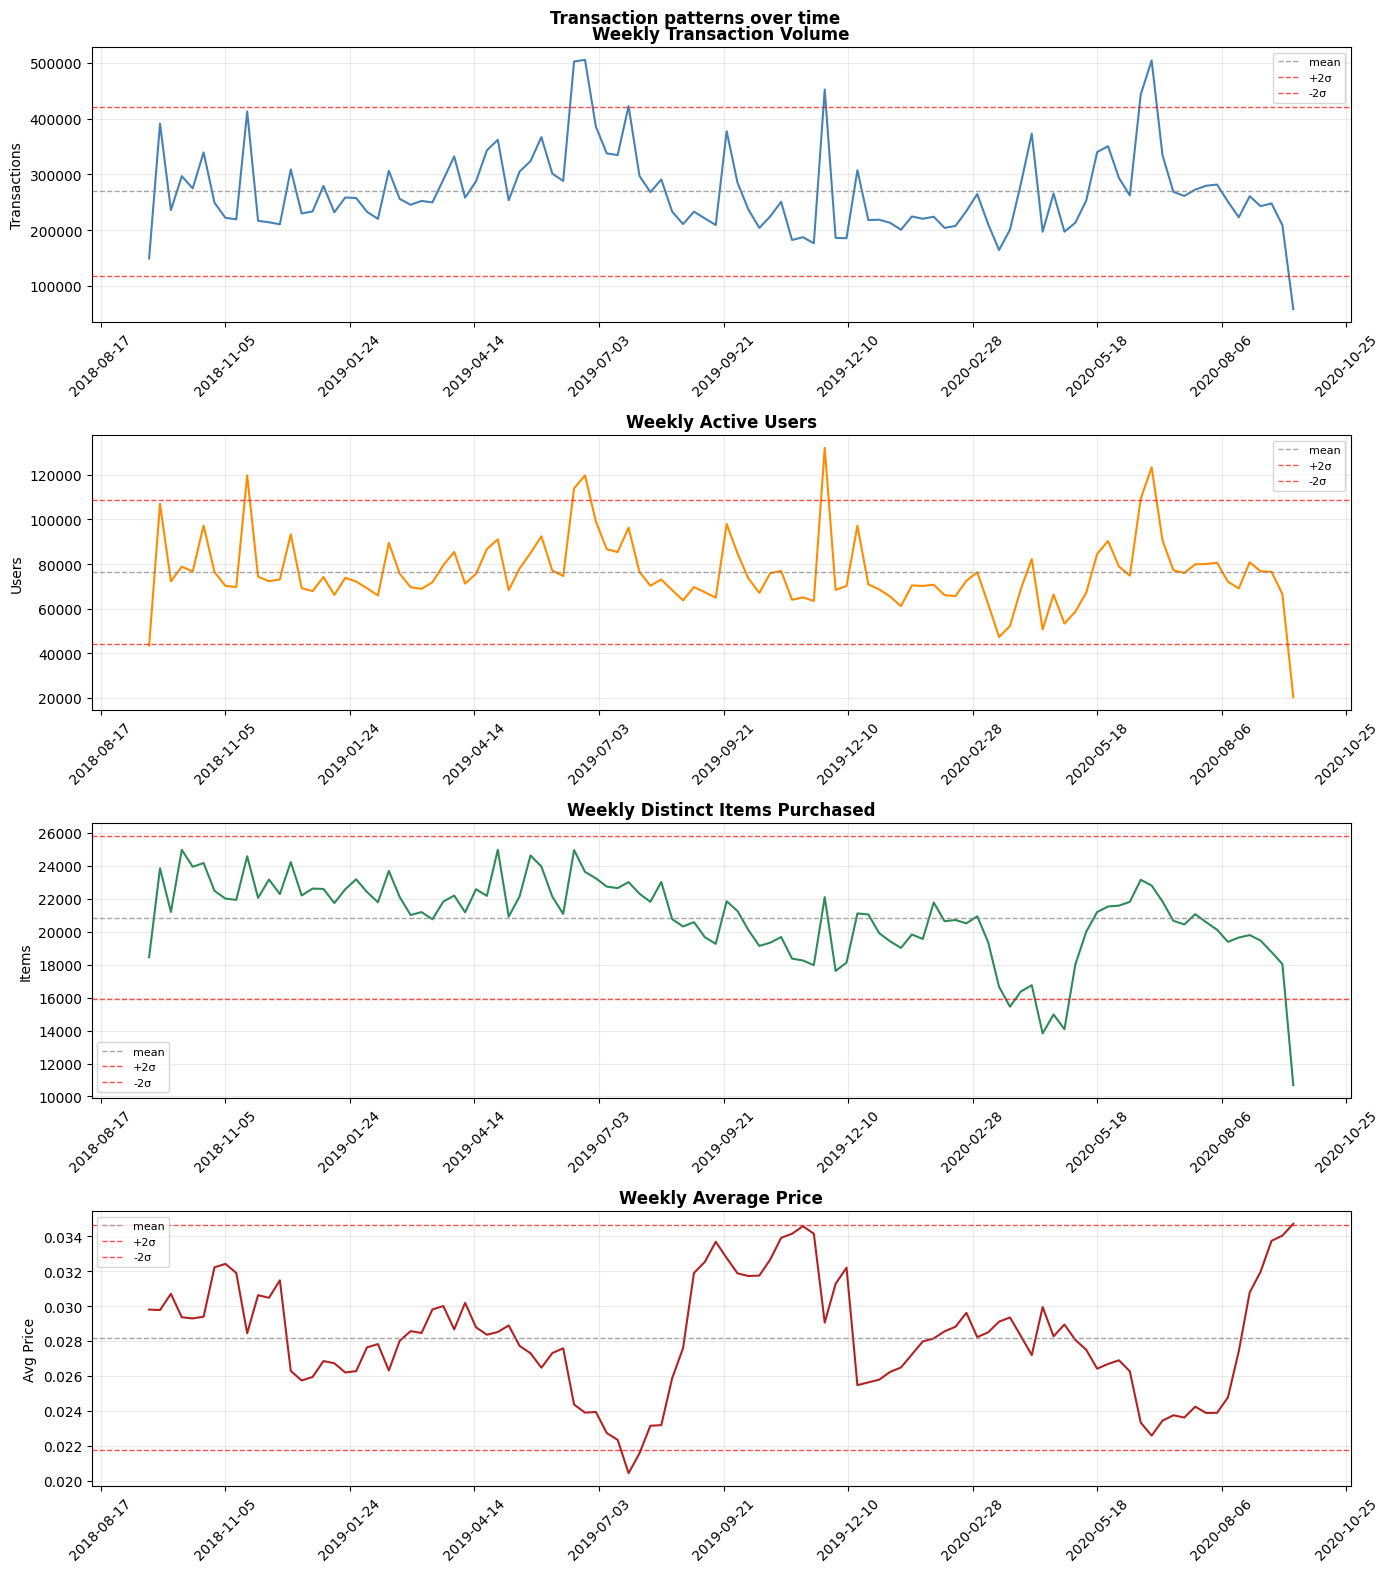

In [ ]:
fig = analyze_transaction_patterns(transactions)

**Finding:** Purchasing behaviour changes over time. Weekly purchases range from under
200k to over 500k, active customers from about 50k to 130k, and the number of different
products sold each week narrows from about 24k to 20k across the two years, dipping to
14k in spring 2020 before recovering. Six weeks stand well above average volume; five of
them fall in June or July, when average prices are at their lowest, which looks like
seasonal sales, though the data carries no promotion labels. Weeks here are calendar
weeks starting on Monday, so the first and last are partial — the data begins on a
Thursday and ends on a Tuesday, and those two partial weeks are excluded from the range
quoted above.

**Implication:** Recent behaviour may be more informative than older behaviour, so how
far back features and training data should reach is something to test rather than fix in
advance. Product-level measures in particular should be built from recent weeks,
since the full history contains products that are no longer in the catalogue. Because weeks differ this much, performance measured on a single week may not be
representative and should be evaluated on multiple weeks.

### 2.3 How concentrated is product demand?

A recommendation system does not need to treat every product equally. If a small number of products account for a large share of purchases, recommending popular products may already provide a strong baseline. 
If demand is more evenly distributed, there may be greater opportunity for personalization to help customers discover less popular but relevant products.

  Concentration & stability:
     Top 1% of items account for 17.9% of purchases.
     Top 10% of items account for 60.2% of purchases.
     Mean week-over-week rank correlation: 0.63


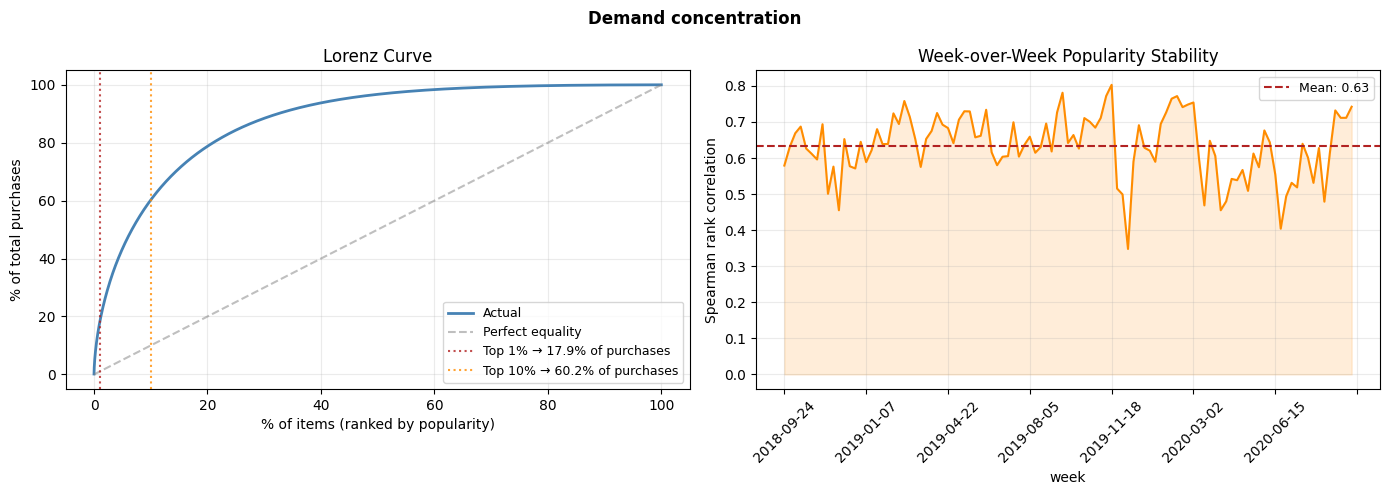

In [ ]:
demand_data = compute_demand_concentration(transactions)

fig = plot_demand_concentration(demand_data)

**Finding:** Demand is concentrated but not extremely so. The best-selling 1% of products (about 1,000 items) account for 18% of all
purchases, and the best-selling 10% (about 10,500 items) account for 60%. Products
outside the top 10% still sell regularly, typically around a hundred times or more. Which products are popular stays fairly stable
from one week to the next.
**Implication:** Popularity is clearly a
real signal, but covering the majority of demand takes thousands of items, so a short
popularity list would only reach a small share of purchases. There is substantial demand outside the bestseller list, and enough
sales history behind it to model. This motivates treating popularity as a strong baseline and testing whether personalization adds value beyond it.

### 2.4 How quickly does product demand change?

Products enter and leave the catalogue continuously. An item that was popular several months ago may no longer be relevant. We therefore examine how purchasing activity changes as products age.

  Item lifecycle:
     50% of items go cold after 15 weeks (survival).
     80% of purchase volume is captured within 29 weeks of launch.
     50% of purchase volume is captured within 11 weeks of launch.


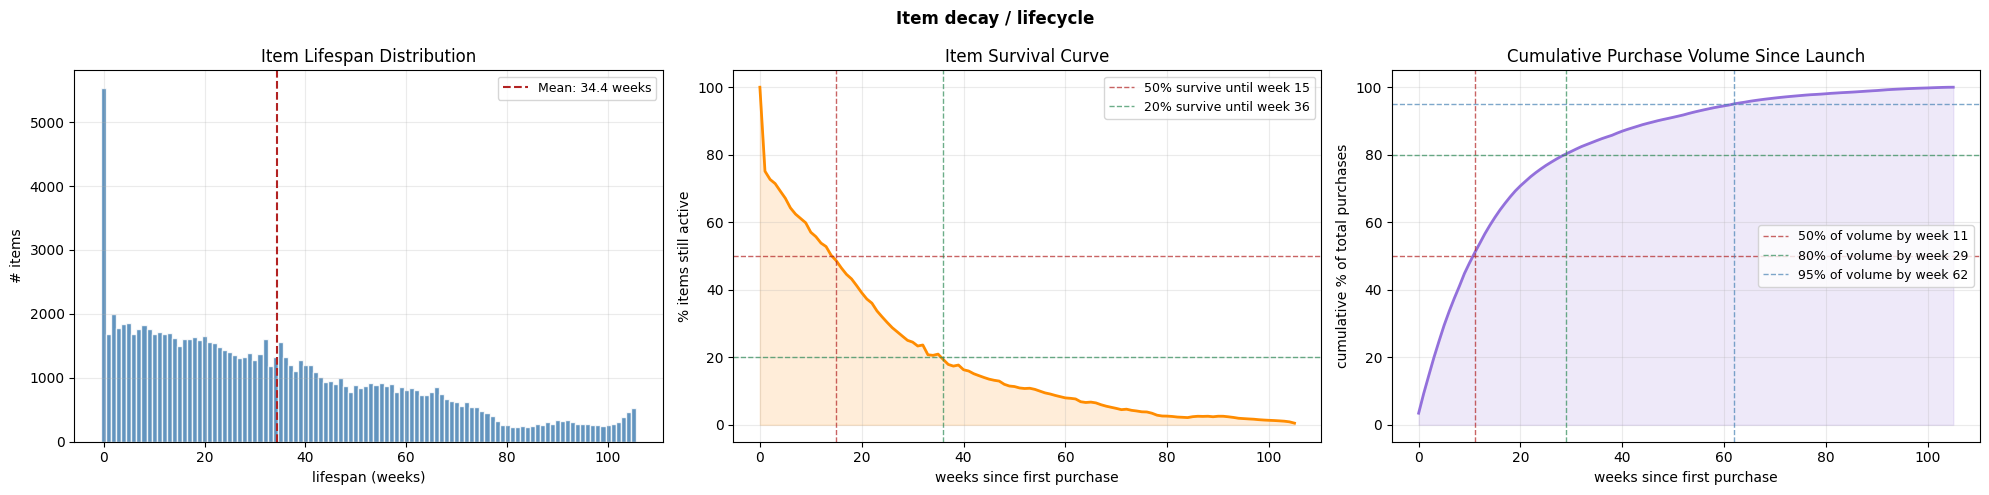

In [ ]:
item_decay_data = compute_item_decay(transactions)
fig = plot_item_decay(item_decay_data)

# the 50%-of-volume point, so the finding below can cite a number that is printed here
volume = item_decay_data["volume_by_week_offset"].sort_values("week_offset")
cumulative = volume["pct_volume"].cumsum()
half_volume = volume.loc[cumulative >= 50, "week_offset"].iloc[0]
print(f"     50% of purchase volume is captured within {half_volume:.0f} weeks of launch.")

**Finding:** Items have short commercial lives, on two different measures. By survival,
half of items have stopped selling 15 weeks after their first sale. By volume timing, half
of an item's total purchases arrive within 11 weeks of launch and 80% within 29 weeks. About 5,500 items sell within a single week, though that figure
is inflated by items launched near the end of the data, which have not had time to sell
for longer.

**Implication:** Item statistics computed over the full two years describe a catalogue
that is largely no longer selling, so recent activity is the more relevant measure. Rather
than fixing a single window, we can supply popularity over several recent windows
alongside item age and time since last sale, and let the model weigh them.

### 2.5 Do customers repurchase products?

A recommendation strategy based heavily on previous purchases only makes sense if customers frequently return to products they have bought before.

We therefore examine both how often customers repurchase the same product and how much of total purchasing behaviour is represented by repurchases.

This helps distinguish two fundamentally different recommendation opportunities:

- **replenishment:** bringing customers back to products they already know;
- **discovery:** helping customers find products they have not purchased before.

 repurchase_rate_pct  repurchase_share_pct  median_days_to_repurchase  mean_days_to_repurchase
               27.71                  4.44                          7                     44.2

Total repurchase pairs: 1,141,216

  Repurchase behaviour:
     27.7% of users ever repurchased the same item.
     4.4% of all transactions are repurchases.
     Median time to repurchase: 7 days.


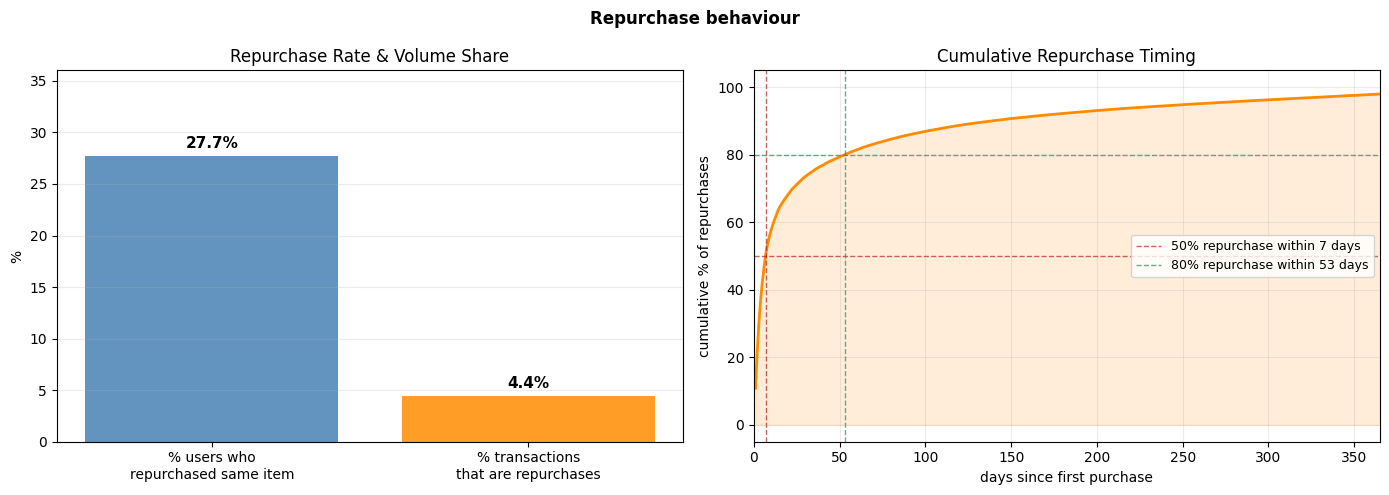

In [ ]:
repurchase_data = compute_repurchase(transactions)
print(repurchase_data["summary"].to_string(index=False))

time_to_repurchase = repurchase_data["time_to_repurchase"]
print(f"\nTotal repurchase pairs: {time_to_repurchase['n_pairs'].sum():,}")

fig = plot_repurchase(repurchase_data)

**Finding:** Just over a quarter of customers have rebought the same product at least
once, but repeat purchases make up only 4.4% of all sales — and half of them happen
within a week.

**Implication:** Most of what we need to predict is a product the customer has never
bought, so recommending past purchases can only cover a small part of the problem. It may still be worth including as a narrow but precise signal, particularly for very recent purchases.

### 2.6 How recently have customers been active?
Customer activity is another important consideration for personalization. A customer's historical preferences are more likely to remain useful when they have interacted with the business recently.

We therefore examine how long it has been since each customer's most recent purchase to understand how much of the customer base has recent behavioural information available.

In [ ]:
activity_data = compute_user_activity_segments(transactions)
fig = plot_user_activity_segments(activity_data)

**Finding:** Only 18% of customers purchased in the last four weeks, while around two-thirds have not
purchased in three months or more.

How recently a customer last bought might be a strong, simple signal — recent customers
can be ranked from their own history, while dormant ones carry little fresh signal. For
the majority of customers who are not recently active, a fallback strategy will be needed.

Note: this describes the customer base as a whole rather than next week's buyers, who are
likely to look quite different. Section 3 measures how purchase rates differ across these
groups.

## 3. What predicts next week
The EDA above suggests several potentially useful signals: recent product demand, previous purchases, product attributes, and customer activity. We now test these signals against the actual prediction task using multiple time-based validation weeks.

The goal is not to find the final model here, but to establish which signals are useful and therefore worth incorporating into the recommender. For this analysis we use time-based splitting: each held-out week is predicted using only the transactions that precede it, and every window below is measured back from the last day of that history.

In [ ]:
N_FOLDS = 6
last_date = transactions.agg(F.max(DATE)).collect()[0][0]
fold_week_ends = [last_date - timedelta(days=7 * weeks_back) for weeks_back in range(N_FOLDS)]

# Every window below is measured back from the last day of history, never from the
# validation week itself, and uses one shared set of lookbacks so no section can drift.
BESTSELLER_WEEKS = 1    # what "recently popular" means
SEED_WEEKS       = 4    # what "recently bought" means
AFFINITY_WEEKS   = 12   # what "an active customer" means


def history_end_of(week_end):
    """Last day of history available when predicting the week ending `week_end`."""
    return week_end - timedelta(weeks=1)


print(f"data ends {last_date}; evaluating {N_FOLDS} held-out weeks ending: "
      + ", ".join(str(week_end) for week_end in fold_week_ends))
print(f"lookbacks: bestsellers {BESTSELLER_WEEKS}w, recent purchases {SEED_WEEKS}w, "
      f"active customer {AFFINITY_WEEKS}w")

data ends 2020-09-22; evaluating 6 held-out weeks ending: 2020-09-22, 2020-09-15, 2020-09-08, 2020-09-01, 2020-08-25, 2020-08-18
lookbacks: bestsellers 1w, recent purchases 4w, active customer 12w


### 3.1 How much of next week's demand can simple rules cover?

A useful first question is how much of next week's demand can be explained by simple links to a customer's previous purchases or by recent popularity.

We classify each next-week purchase into the first applicable group: exact repeat, another variant of a previously purchased product, same product type, recent bestseller, or not covered by these simple rules. This shows how much of next-week demand can be explained by simple signals, and where they leave gaps.

In [ ]:
article_attrs = articles.select(ITEM, "product_code", "product_type_no")
decomposition_rows, new_arrival_share, unseen_share = [], [], []
for week_end in fold_week_ends:
    history, next_purchases = make_fold(transactions, week_end)
    history = history.cache()
    next_purchases = next_purchases.cache()
    history_end = history_end_of(week_end)
    n_next = next_purchases.count()
    past_pairs = history.select(CUSTOMER, ITEM).distinct()
    past_attrs = history.join(article_attrs, ITEM).select(CUSTOMER, "product_code", "product_type_no").cache()
    past_codes = past_attrs.select(CUSTOMER, "product_code").distinct()
    past_types = past_attrs.select(CUSTOMER, "product_type_no").distinct()
    recent_bestsellers = (history.filter(F.col(DATE) > F.lit(history_end - timedelta(weeks=BESTSELLER_WEEKS)))
                          .groupBy(ITEM).count().orderBy(F.col("count").desc()).limit(200).select(ITEM))
    tagged = (next_purchases.join(article_attrs, ITEM, "left")
              .join(past_pairs.withColumn("is_repeat", F.lit(1)), [CUSTOMER, ITEM], "left")
              .join(past_codes.withColumn("is_sibling", F.lit(1)), [CUSTOMER, "product_code"], "left")
              .join(past_types.withColumn("is_category", F.lit(1)), [CUSTOMER, "product_type_no"], "left")
              .join(F.broadcast(recent_bestsellers).withColumn("is_popular", F.lit(1)), ITEM, "left"))
    bucket = (
        F.when(F.col("is_repeat") == 1, "1 repeat (exact item)")
        .when(F.col("is_sibling") == 1, "2 sibling (same product, new variant)")
        .when(F.col("is_category") == 1, "3 product type (same type, new product)")
        .when(F.col("is_popular") == 1, "4 popular (recent best-seller)")
        .otherwise("5 not covered by simple rules")
    )
    counts = {row["bucket"]: row["count"]
              for row in tagged.withColumn("bucket", bucket).groupBy("bucket").count().collect()}
    bucket_names = [
        "1 repeat (exact item)",
        "2 sibling (same product, new variant)",
        "3 product type (same type, new product)",
        "4 popular (recent best-seller)",
        "5 not covered by simple rules",
    ]

    decomposition_rows.append({
        bucket_name: 100 * counts.get(bucket_name, 0) / n_next
        for bucket_name in bucket_names
    })


    # launch dates come from THIS fold's history: taking them from the full table would
    # let an item's later launch date decide whether it was "new" in an earlier fold
    item_first_sale = history.groupBy(ITEM).agg(F.min(DATE).alias("first_sale_date"))
    new_items = item_first_sale.filter(
        F.col("first_sale_date") > F.lit(history_end - timedelta(weeks=SEED_WEEKS))).select(ITEM)
    new_arrival_share.append(100 * next_purchases.join(new_items, ITEM).count() / n_next)
    unseen_share.append(
        100 * next_purchases.join(item_first_sale.select(ITEM), ITEM, "leftanti").count() / n_next)
    past_attrs.unpersist(); history.unpersist(); next_purchases.unpersist()

decomposition = pd.DataFrame(decomposition_rows).mean().round(1)
print(f"next-week purchase breakdown (average of {N_FOLDS} held-out weeks):")
print(decomposition.to_string())
print(f"\nlaunched within {SEED_WEEKS}w of the end of history: "
      f"{sum(new_arrival_share)/len(new_arrival_share):.1f}% of next-week buys")
print(f"never sold before the prediction week:      "
      f"{sum(unseen_share)/len(unseen_share):.1f}% of next-week buys")

next-week purchase breakdown (average of 6 held-out weeks):
1 repeat (exact item)                       3.9
2 sibling (same product, new variant)       5.0
3 product type (same type, new product)    55.9
4 popular (recent best-seller)              5.3
5 not covered by simple rules              29.9

launched within 4w of the end of history: 29.0% of next-week buys
never sold before the prediction week:      3.8% of next-week buys


**Finding:** 55.9% of next-week purchases are of a product type the customer has bought before, while exact repeats account for 3.9% and new variants of a known product 5.0%. About 30% match none of these four rules. Products launched within four weeks of the end of history account for 29.0% of next-week purchases, and a further 3.8% are of items with no sales history at all.

**Implication:** A large share of purchases sit in product types customers have bought before, which makes category affinity worth testing as a candidate-generation signal — though coverage alone does not establish that it will rank well. The 30% figure is a limit on *these four rules*, not a measure of what a model can learn; reaching it plausibly needs something that relates products to each other rather than to the customer's own history.

### 3.2 Which product attributes show customer preference?

Exact item history is sparse, so we test whether customers tend to stay within product attributes they have purchased before. We compare the observed match rate with the rate expected from the overall prevalence of each attribute value.

In [ ]:
attribute_columns = {"product_code": "product_code", "product_type": "product_type_no",
                     "department": "department_no", "section": "section_no", "colour": "colour_group_code",
                     "garment_group": "garment_group_no", "index_group": "index_group_no"}
loyalty_rows = []
for week_end in fold_week_ends:
    history, next_purchases = make_fold(transactions, week_end)
    history = history.cache()
    next_purchases = next_purchases.cache()
    n_next = next_purchases.count()
    n_customers = history.select(CUSTOMER).distinct().count()
    for name, col in attribute_columns.items():
        attribute = articles.select(ITEM, col)
        bought_values = history.join(attribute, ITEM).select(CUSTOMER, col).distinct()
        next_with_value = next_purchases.join(attribute, ITEM)
        match = next_with_value.join(bought_values, [CUSTOMER, col]).select(CUSTOMER, ITEM).distinct().count() / n_next
        chance = (next_with_value
                  .join(bought_values.groupBy(col).count().withColumnRenamed("count", "buyers_of_value"), col)
                  .agg(F.avg(F.col("buyers_of_value") / n_customers)).collect()[0][0])
        loyalty_rows.append({"attribute": name, "match %": 100 * match, "chance %": 100 * chance})
    history.unpersist(); next_purchases.unpersist()

loyalty_folds = pd.DataFrame(loyalty_rows)
loyalty = (loyalty_folds.groupby("attribute")[["match %", "chance %"]].mean()
           .assign(lift=lambda stats: stats["match %"] / stats["chance %"])
           .sort_values("lift", ascending=False))
loyalty["match sd"] = loyalty_folds.groupby("attribute")["match %"].std()

loyalty.round(2)

**Finding:** The attributes with the highest match rates are the least distinctive. Index group matches 87% of next-week purchases but exceeds its prevalence-based expectation by only 1.2×, while product code matches 9% at 17×. Department is the strongest of the broad attributes at 3.3×; colour and index group sit closest to expectation.

**Implication:** Product- and department-level attributes show stronger customer-specific persistence than broader ones, making them the first affinity features to test. The comparison is against a prevalence-based expectation and customer histories differ a lot in breadth, so this ranks the attributes against each other rather than settling which are worth keeping.

### 3.3 Which customers are most likely to buy next week?

We compare next-week purchase rates across customers with different levels of recency, purchase history, and engagement to identify which customer-level signals are useful for predicting future activity.

In [ ]:
who_rows = []
cold_share_rows = []

for week_end in fold_week_ends:
    history, next_purchases = make_fold(transactions, week_end)
    history = history.cache()
    next_purchases = next_purchases.cache()

    history_end = history_end_of(week_end)

    next_buyers = (
        next_purchases
        .select(CUSTOMER)
        .distinct()
        .withColumn("bought", F.lit(1))
        .cache()
    )

    n_buyers = next_buyers.count()

    customer_stats = (
        history
        .groupBy(CUSTOMER)
        .agg(
            F.datediff(
                F.lit(history_end),
                F.max(DATE)
            ).alias("days_since_last"),
            F.count("*").alias("purchases")
        )
        .join(
            customers.select(CUSTOMER, "fashion_news_frequency"),
            CUSTOMER,
            "left"
        )
        .join(next_buyers, CUSTOMER, "left")
        .fillna({"bought": 0})
    )

    row = customer_stats.agg(
        F.avg("bought").alias("base"),

        F.avg(
            F.when(F.col("days_since_last") <= 7 * SEED_WEEKS, F.col("bought"))
        ).alias("recent"),

        F.avg(
            F.when(F.col("days_since_last") > 7 * AFFINITY_WEEKS, F.col("bought"))
        ).alias("dormant"),

        F.avg(
            F.when(F.col("purchases") >= 10, F.col("bought"))
        ).alias("frequent"),

        F.avg(
            F.when(F.col("purchases") == 1, F.col("bought"))
        ).alias("one-time"),

        F.avg(
            F.when(
                F.col("fashion_news_frequency") == "Regularly",
                F.col("bought")
            )
        ).alias("newsletter"),

        F.avg(
            F.when(
                F.col("fashion_news_frequency").isin("NONE", "None"),
                F.col("bought")
            )
        ).alias("no-news"),

    ).collect()[0].asDict()

    who_rows.append(row)

    # Share of next-week buyers with no prior history
    cold_buyers = (
        next_buyers
        .join(
            history.select(CUSTOMER).distinct(),
            CUSTOMER,
            "leftanti"
        )
        .count()
    )

    cold_share_rows.append(cold_buyers / n_buyers)

    history.unpersist()
    next_buyers.unpersist()
    next_purchases.unpersist()


# Average across folds
who = pd.DataFrame(who_rows).mean()
who_sd = pd.DataFrame(who_rows).std()
cold_share = np.mean(cold_share_rows)

base = who["base"]

who_table = pd.DataFrame({
    "buy-rate %": 100 * who[["recent", "frequent", "newsletter", "no-news", "dormant", "one-time"]],
    "sd": 100 * who_sd[["recent", "frequent", "newsletter", "no-news", "dormant", "one-time"]],
})
who_table["lift"] = who_table["buy-rate %"] / (100 * base)
who_table.attrs["base %"] = 100 * base

print(f"base {base:.1%} among customers with any prior history; "
      f"recent = bought within {SEED_WEEKS}w, dormant = nothing for {AFFINITY_WEEKS}w+; "
      f"cold-start buyers {cold_share:.1%}")
who_table.round(2)

**Finding:** Among customers with prior purchase history (base rate 5.1%), those who bought within the last four weeks are 2.7× as likely to buy again next week, while dormant (0.34×) and one-time (0.14×) customers are much less likely. These groups overlap rather than partition the base — a recent customer may also be a frequent one. A separate 7.3% of next-week buyers have no prior history at all and fall outside this population.

**Implication:** Recency and purchase frequency are the strongest customer-level signals here and are worth testing as core ranking features, with separate treatment of active and inactive customers.

### 3.4 Do customers remain consistent in what they buy?

Consistency across purchases (average of 6 weeks):
  channel   75% vs 52% (1.45×) (binary, so chance is high by construction)
  price     43% vs 33% (1.32×)
  category  65% vs 59% (1.10×)


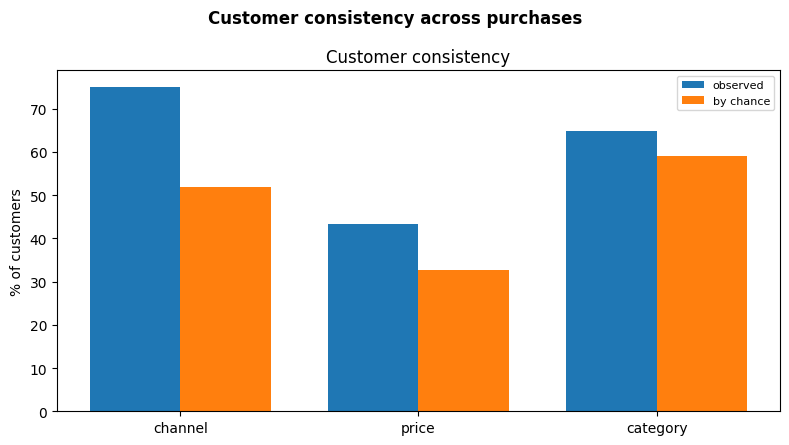

In [ ]:
consistency_rows = []

for week_end in fold_week_ends:
    history, next_purchases = make_fold(transactions, week_end)
    history = history.cache()
    next_purchases = next_purchases.cache()

    # price / channel live on the transaction rows, which `next_purchases` drops when it
    # reduces the week to distinct (customer, item) pairs — so read the week itself.
    week_start = week_end - timedelta(days=6)
    next_week = transactions.filter(
        (F.col(DATE) >= F.lit(week_start)) & (F.col(DATE) <= F.lit(week_end))
    ).cache()

    # Price consistency
    hist_price = (
        history
        .groupBy(CUSTOMER)
        .agg(F.avg("price").alias("p"))
    )

    cuts = hist_price.approxQuantile(
        "p",
        [0.33, 0.66],
        0.01
    )

    next_price = (
        next_week
        .groupBy(CUSTOMER)
        .agg(F.avg("price").alias("p"))
    )

    obs_price, chance_price = consistency(
        hist_price.select(
            CUSTOMER,
            price_tier(F.col("p"), cuts).alias("usual")
        ),
        next_price.select(
            CUSTOMER,
            price_tier(F.col("p"), cuts).alias("next_val")
        )
    )

    # Channel consistency
    obs_channel, chance_channel = consistency(
        history
        .groupBy(CUSTOMER)
        .agg(
            (F.avg("sales_channel_id") > 1.5)
            .cast("int")
            .alias("usual")
        ),
        next_week
        .groupBy(CUSTOMER)
        .agg(
            (F.avg("sales_channel_id") > 1.5)
            .cast("int")
            .alias("next_val")
        )
    )

    # Category consistency
    index_group = articles.select(
        ITEM,
        "index_group_no"
    )

    obs_category, chance_category = consistency(
        top_index(
            history,
            "usual",
            index_group
        ),
        top_index(
            next_purchases,
            "next_val",
            index_group
        )
    )

    consistency_rows.append({
        "price": (obs_price, chance_price),
        "channel": (obs_channel, chance_channel),
        "category": (obs_category, chance_category)
    })

    next_week.unpersist()
    history.unpersist()
    next_purchases.unpersist()


# Average across folds
consistency_avg = {
    dimension: (
        np.mean([
            fold[dimension][0]
            for fold in consistency_rows
        ]),
        np.mean([
            fold[dimension][1]
            for fold in consistency_rows
        ])
    )
    for dimension in ["channel", "price", "category"]
}


print(
    f"Consistency across purchases "
    f"(average of {N_FOLDS} weeks):"
)

for dimension, (observed, chance) in consistency_avg.items():
    floor = " (binary, so chance is high by construction)" if dimension == "channel" else ""
    print(
        f"  {dimension:9s} "
        f"{observed:.0%} vs {chance:.0%} "
        f"({observed / chance:.2f}×){floor}"
    )


# Plot
dimensions = ["channel", "price", "category"]
x = np.arange(len(dimensions))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    x - width / 2,
    [consistency_avg[d][0] * 100 for d in dimensions],
    width,
    label="observed"
)

ax.bar(
    x + width / 2,
    [consistency_avg[d][1] * 100 for d in dimensions],
    width,
    label="by chance"
)

ax.set_xticks(x)
ax.set_xticklabels(dimensions)
ax.set_ylabel("% of customers")
ax.set_title("Customer consistency")
ax.legend(fontsize=8)

chart_title(fig, "Customer consistency across purchases")
plt.tight_layout()

**Finding:** Consistency with a customer's usual behaviour is modest once chance is accounted for: channel 75% vs 52% (1.45×), price tier 43% vs 33% (1.32×), and category 65% vs 59% (1.10×). Channel is a binary split, so its chance rate is high by construction and the ratio overstates how much it separates.

**Implication:** None of these is strong enough on its own to justify a ranking feature. Price and channel are at most worth carrying alongside stronger signals, and should be judged by whether they improve ranking performance rather than by this table.

## 4. What the data tells us to build

The analysis above produces hypotheses rather than proven components — each still has to be validated by whether it improves candidate generation or ranking.

- **Baseline** — popularity. Demand is concentrated enough (the top 10% of items carry 60% of purchases) that a non-personalized list is the bar everything else has to clear.
- **Candidate sources to test** — recent popularity; repurchase, small but precise; category and content affinity, which covers the largest share of next-week purchases; and a collaborative or embedding source for the demand that no history-based rule reaches.
- **Ranking features to test** — customer recency and frequency; item recency and popularity over recent windows; product- and department-level affinity; price and channel only if they earn their place.
- **Fallback** — popularity, and demographic popularity for the share of next-week buyers with no history of their own.

In [ ]:
spark.stop()